# Descriptive distributions: the seven factors by outcome

Before running PRIM/CART, build intuition: for each of the seven pathway factors, plot its
distribution at **2030** and at **2050** split by outcome, plus the CO2 trajectory and the shape of
the desired region. The point is to see which factors visibly separate the desired pathways
(net zero by 2070 *and* low CCS reliance) from the rest, and at which horizon.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

FACTORS = [
    "Emissions|CO2",
    "Primary Energy|Fossil",
    "Primary Energy|Biomass",
    "Primary Energy|Non-Biomass Renewables",
    "Carbon Capture|Geological Storage|Biomass",
    "Final Energy|Electricity",
    "Climate Assessment|Surface Temperature (GSAT)|Median [MAGICCv7.5.3]",
]
SNAPSHOT_YEARS = [2030, 2050]

In [2]:
df = pd.read_csv("data_for_scenariodiscovery_full.csv")
for c in ["success_nz2070", "low_ccs_reliance", "desired_success"]:
    df[c] = df[c].astype(bool)

# two-way split on net-zero success, and a three-way split that also separates the two routes to
# net zero: low-CCS "desired" successes vs high-CCS successes vs outright failures (equifinality).
df["group"] = np.where(
    df["success_nz2070"], "Success (NZ ≤ 2070)", "Failure (NZ > 2070 or never)"
)

CAT_DESIRED = "Desired (NZ≤2070 & low CCS)"
CAT_HIGH_CCS = "NZ≤2070 but high CCS"
CAT_FAILURE = "Failure (no NZ by 2070)"
df["category"] = np.where(
    df["desired_success"], CAT_DESIRED,
    np.where(df["success_nz2070"], CAT_HIGH_CCS, CAT_FAILURE),
)

GROUP_PALETTE = {"Success (NZ ≤ 2070)": "#2a9d8f", "Failure (NZ > 2070 or never)": "#e76f51"}
CAT_PALETTE = {CAT_DESIRED: "#2a9d8f", CAT_HIGH_CCS: "#f4a261", CAT_FAILURE: "#e76f51"}

print(df["category"].value_counts())

category
Failure (no NZ by 2070)        1102
Desired (NZ≤2070 & low CCS)     372
NZ≤2070 but high CCS            125
Name: count, dtype: int64


/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/573823929.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["group"] = np.where(
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/573823929.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["category"] = np.where(


## Factor coverage at each snapshot year

In [3]:
for year in SNAPSHOT_YEARS:
    print(f"--- {year} ---")
    for v in FACTORS:
        col = f"{v}|{year}"
        print(f"  {col[:62]:62s} missing={df[col].isna().mean():5.1%}  n={df[col].notna().sum()}")
    print()

--- 2030 ---
  Emissions|CO2|2030                                             missing= 0.9%  n=1584
  Primary Energy|Fossil|2030                                     missing= 1.5%  n=1575
  Primary Energy|Biomass|2030                                    missing= 1.3%  n=1578
  Primary Energy|Non-Biomass Renewables|2030                     missing= 8.7%  n=1460
  Carbon Capture|Geological Storage|Biomass|2030                 missing= 8.9%  n=1456
  Final Energy|Electricity|2030                                  missing= 2.6%  n=1558
  Climate Assessment|Surface Temperature (GSAT)|Median [MAGICCv7 missing= 3.6%  n=1541

--- 2050 ---
  Emissions|CO2|2050                                             missing= 0.9%  n=1584
  Primary Energy|Fossil|2050                                     missing= 1.5%  n=1575
  Primary Energy|Biomass|2050                                    missing= 1.3%  n=1578
  Primary Energy|Non-Biomass Renewables|2050                     missing= 8.7%  n=1460
  Carbon Capture

## Distribution of each factor by net-zero outcome

Box + strip plots (robust to the long tails), one figure per snapshot year. The helper below is
reused for the three-way split further down.

/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xticklabels, rotation=15)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xticklabels, rotation=15)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xticklabels, rotation=15)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() shoul

/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xticklabels, rotation=15)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xticklabels, rotation=15)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xticklabels, rotation=15)


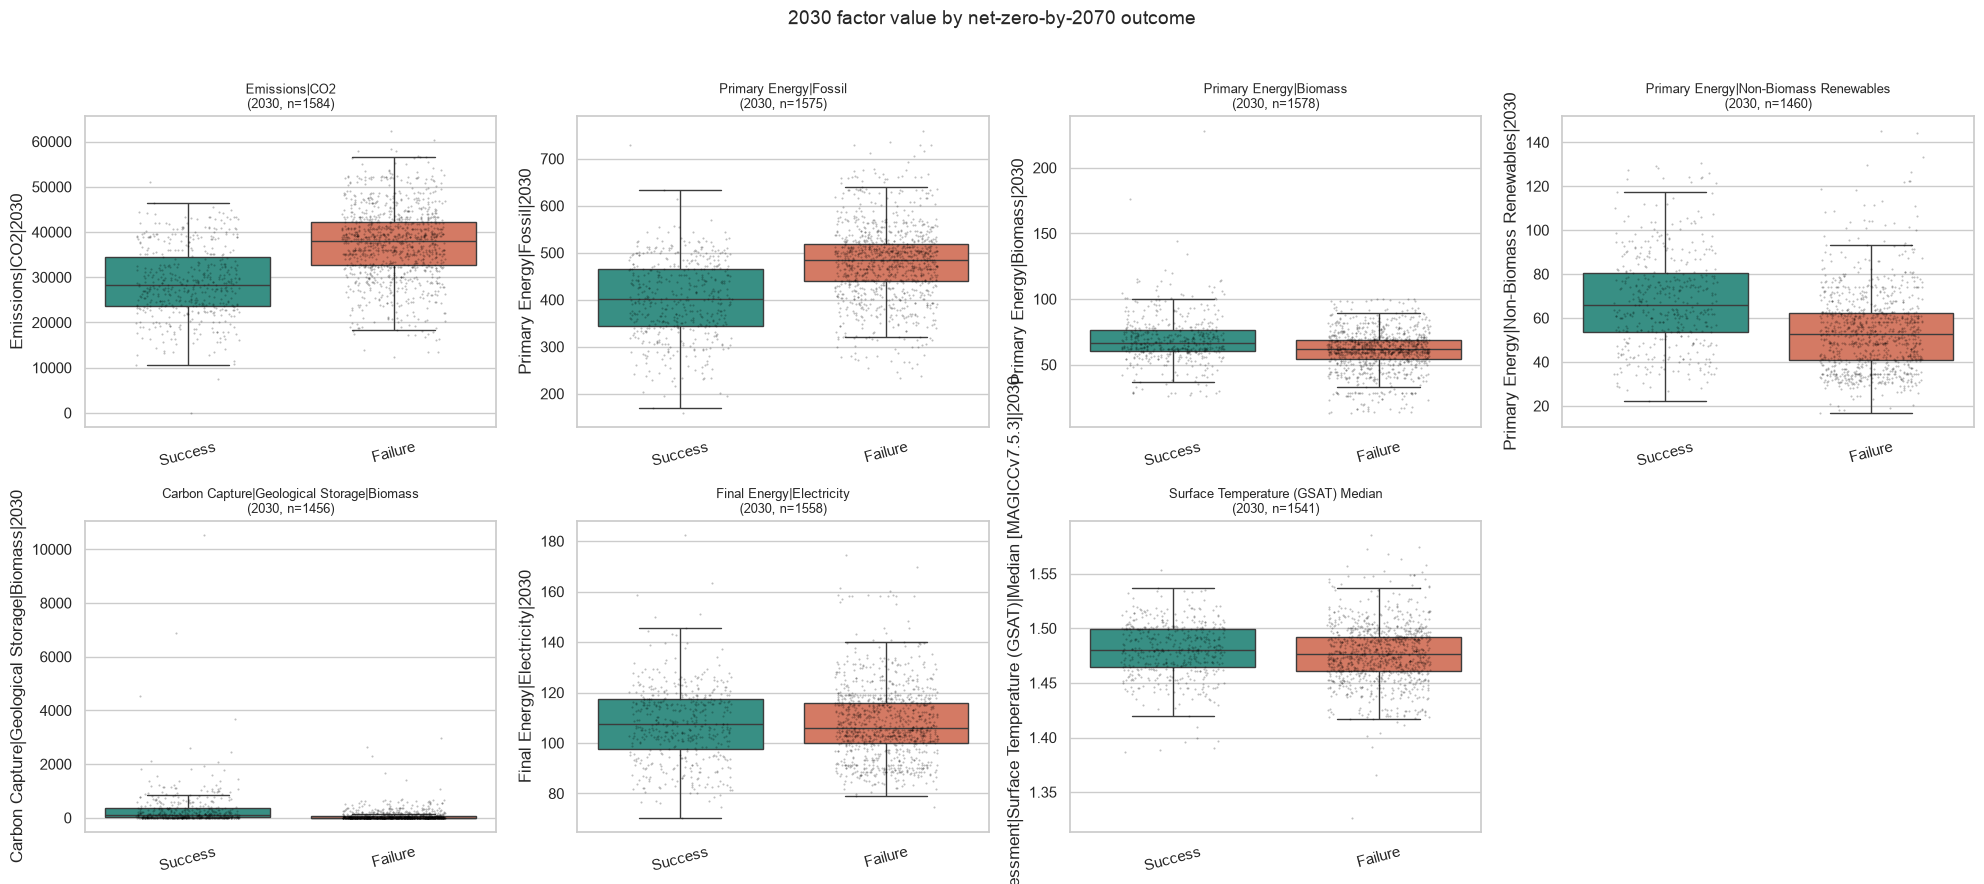

/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xticklabels, rotation=15)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xticklabels, rotation=15)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xticklabels, rotation=15)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() shoul

/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xticklabels, rotation=15)


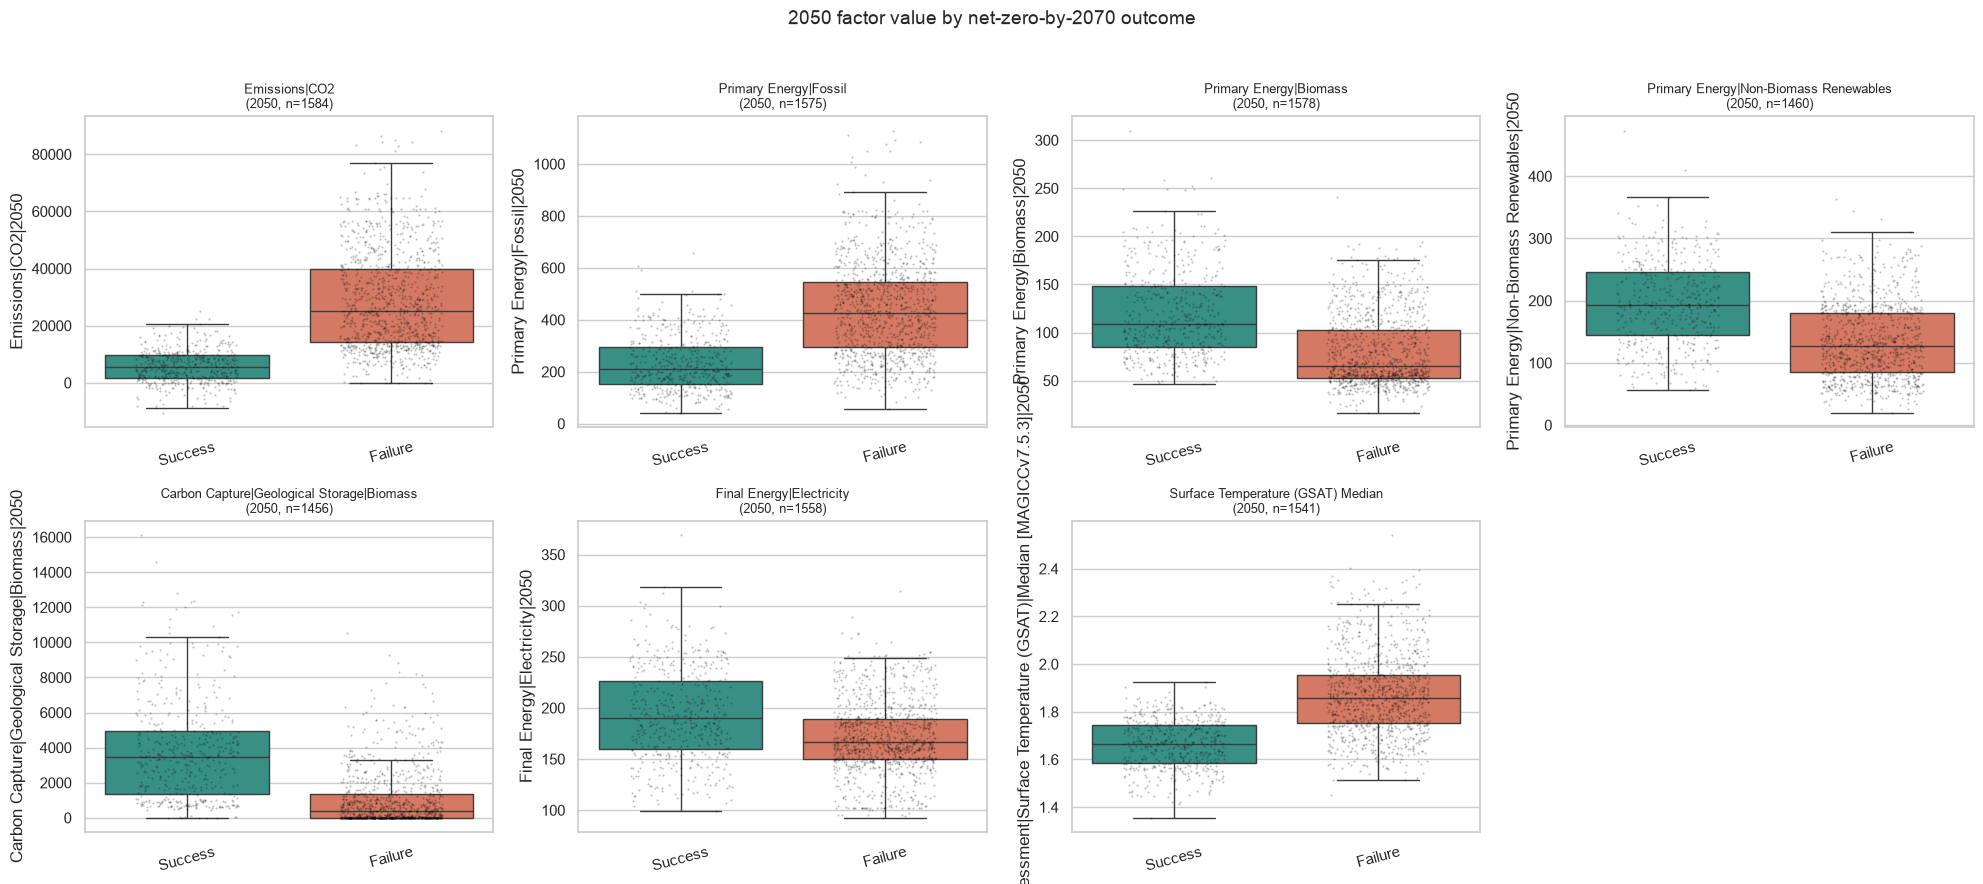

In [4]:
def short(v):
    return v.replace(
        "Climate Assessment|Surface Temperature (GSAT)|Median [MAGICCv7.5.3]",
        "Surface Temperature (GSAT) Median",
    )


def factor_grid(year, hue, palette, order, xticklabels, fname, title, strip=True):
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    axes = axes.flatten()
    for ax, var in zip(axes, FACTORS):
        col = f"{var}|{year}"
        n = df[col].notna().sum()
        sns.boxplot(
            data=df, x=hue, y=col, hue=hue, palette=palette, order=order, hue_order=order,
            ax=ax, legend=False, showfliers=False,
        )
        if strip:
            sns.stripplot(
                data=df, x=hue, y=col, order=order, ax=ax, color="black",
                size=1.5, alpha=0.25, jitter=0.25,
            )
        ax.set_title(f"{short(var)}\n({year}, n={n})", fontsize=9)
        ax.set_xlabel("")
        ax.set_xticklabels(xticklabels, rotation=15)
    for ax in axes[len(FACTORS):]:
        ax.set_visible(False)
    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(fname, dpi=150)
    plt.show()


for year in SNAPSHOT_YEARS:
    factor_grid(
        year, hue="group", palette=GROUP_PALETTE,
        order=["Success (NZ ≤ 2070)", "Failure (NZ > 2070 or never)"],
        xticklabels=["Success", "Failure"],
        fname=f"boxplots_{year}.png",
        title=f"{year} factor value by net-zero-by-2070 outcome",
    )

## Desired vs high-CCS successes vs failures

Same factors, now split three ways. If the desired (low-CCS) group also looks different from the
high-CCS successes on fossil decline, electrification, BECCS, etc., the desired pathways are
mitigating harder elsewhere rather than just using less CCS.

/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xticklabels, rotation=15)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xticklabels, rotation=15)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xticklabels, rotation=15)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() shoul

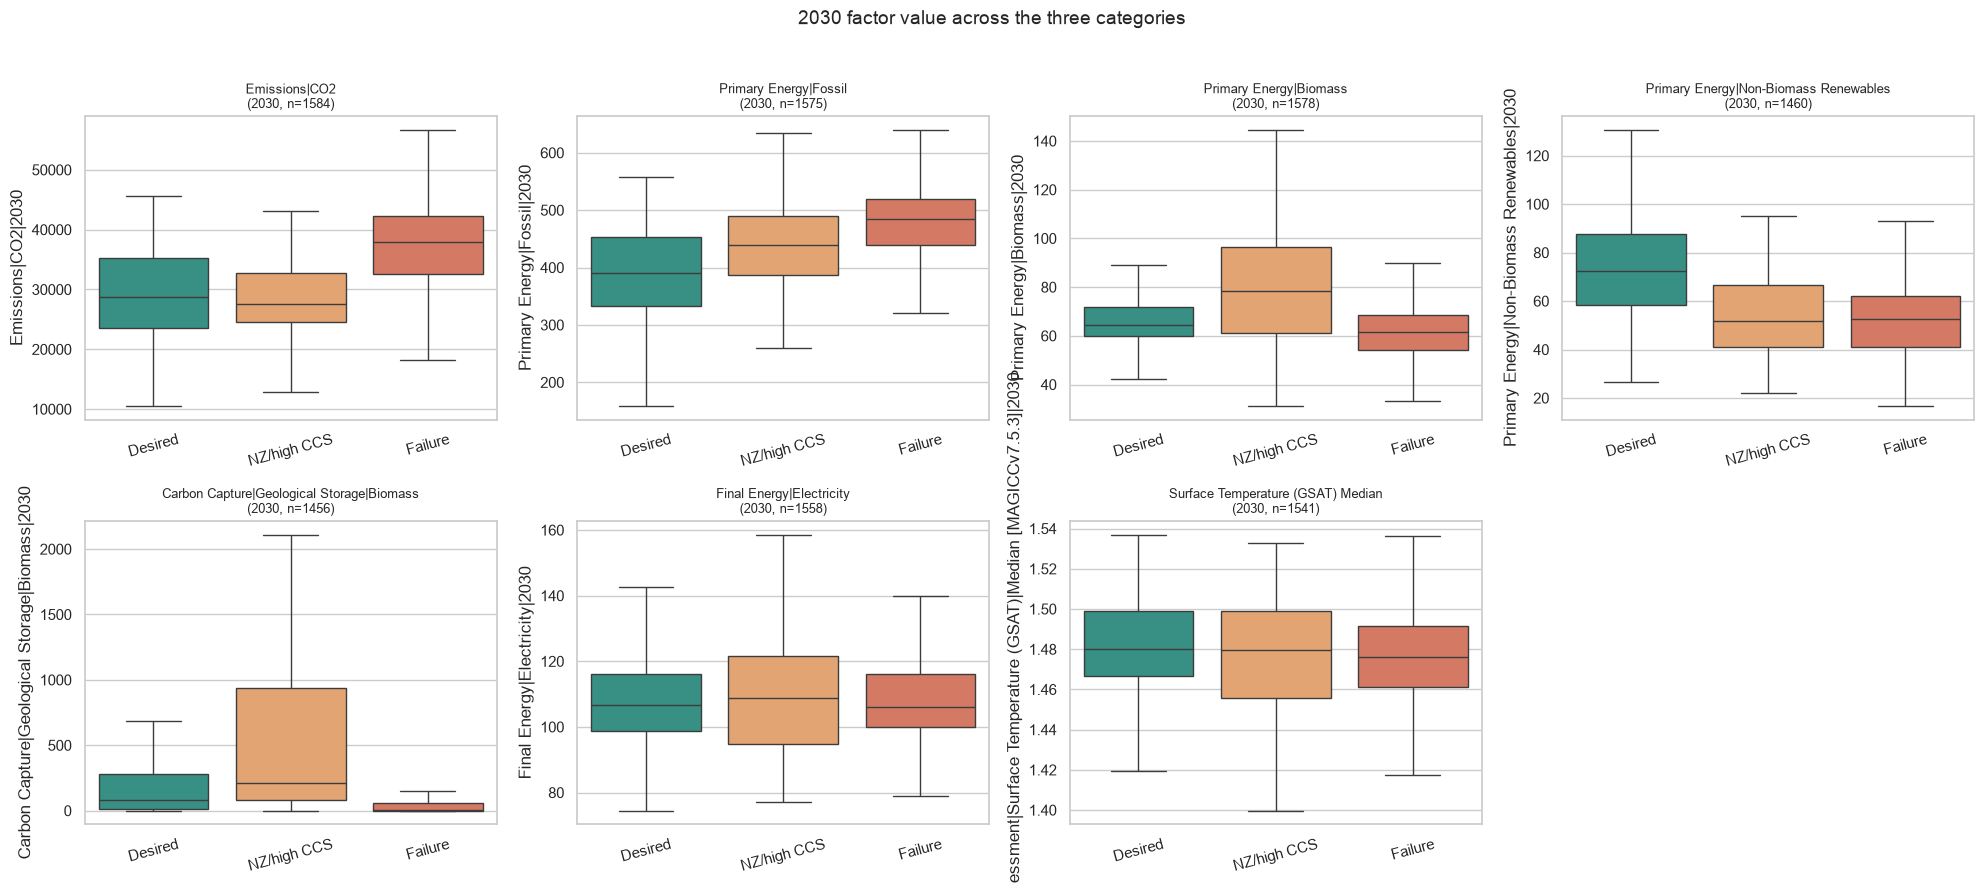

/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xticklabels, rotation=15)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xticklabels, rotation=15)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xticklabels, rotation=15)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_47877/3027724451.py:25: UserWarning: set_ticklabels() shoul

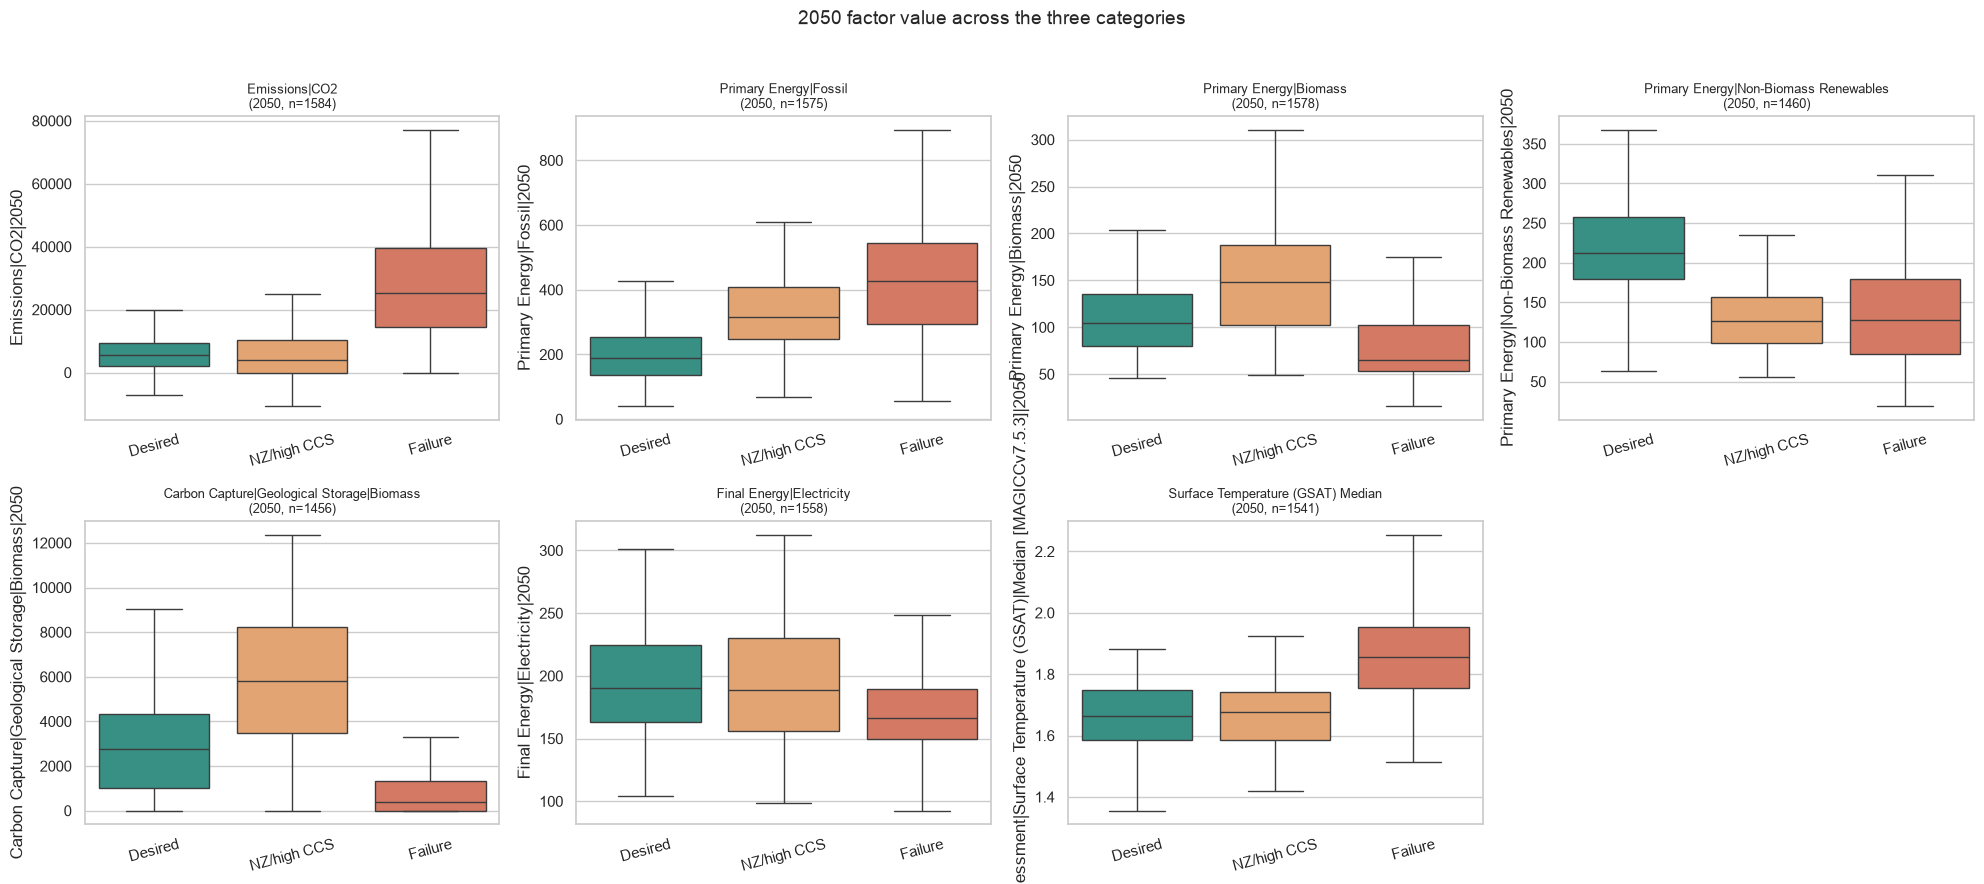

In [5]:
for year in SNAPSHOT_YEARS:
    factor_grid(
        year, hue="category", palette=CAT_PALETTE, order=list(CAT_PALETTE),
        xticklabels=["Desired", "NZ/high CCS", "Failure"],
        fname=f"boxplots_{year}_threeway.png",
        title=f"{year} factor value across the three categories",
        strip=False,
    )

## CO2 emissions trajectory: median + IQR band by outcome

The one view that uses the full trajectory rather than a single-year snapshot.

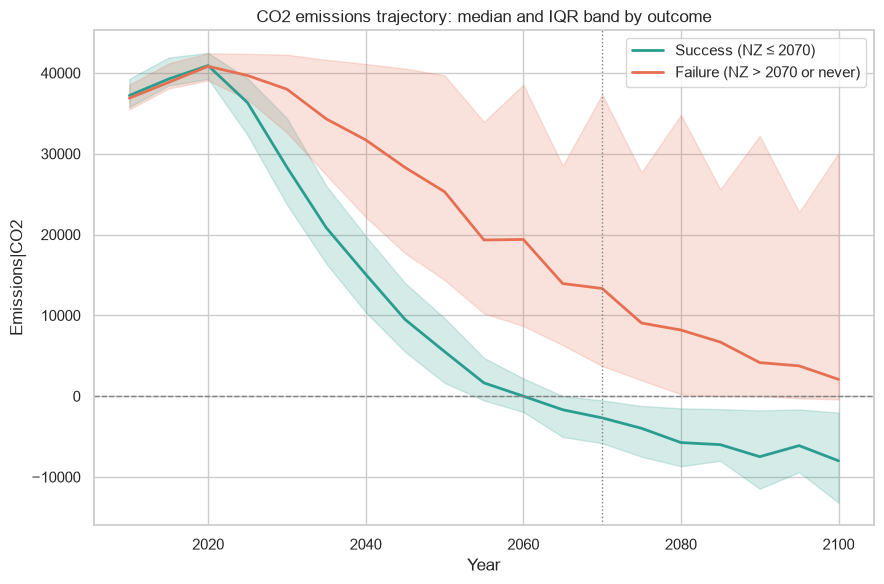

In [6]:
co2_cols = sorted(
    [c for c in df.columns if c.startswith("Emissions|CO2|")],
    key=lambda c: int(c.split("|")[-1]),
)
years = [int(c.split("|")[-1]) for c in co2_cols]

fig, ax = plt.subplots(figsize=(9, 6))
for label, color in GROUP_PALETTE.items():
    sub = df.loc[df["group"] == label, co2_cols]
    ax.plot(years, sub.median().values, label=label, color=color, linewidth=2)
    ax.fill_between(years, sub.quantile(0.25).values, sub.quantile(0.75).values,
                    color=color, alpha=0.2)
ax.axhline(0, color="grey", lw=1, ls="--")
ax.axvline(2070, color="grey", lw=1, ls=":")
ax.set_xlabel("Year")
ax.set_ylabel("Emissions|CO2")
ax.set_title("CO2 emissions trajectory: median and IQR band by outcome")
ax.legend()
fig.tight_layout()
fig.savefig("co2_trajectories.png", dpi=150)
plt.show()

## The desired region in (net-zero year, cumulative CCS) space

The outcome is a rectangle in this plane: net zero at or before 2070, cumulative CCS at or below the
1000 Gt threshold. The CCS split breaks the "success" group into the desired pathways and the ones
that reach net zero leaning on above-threshold CCS.

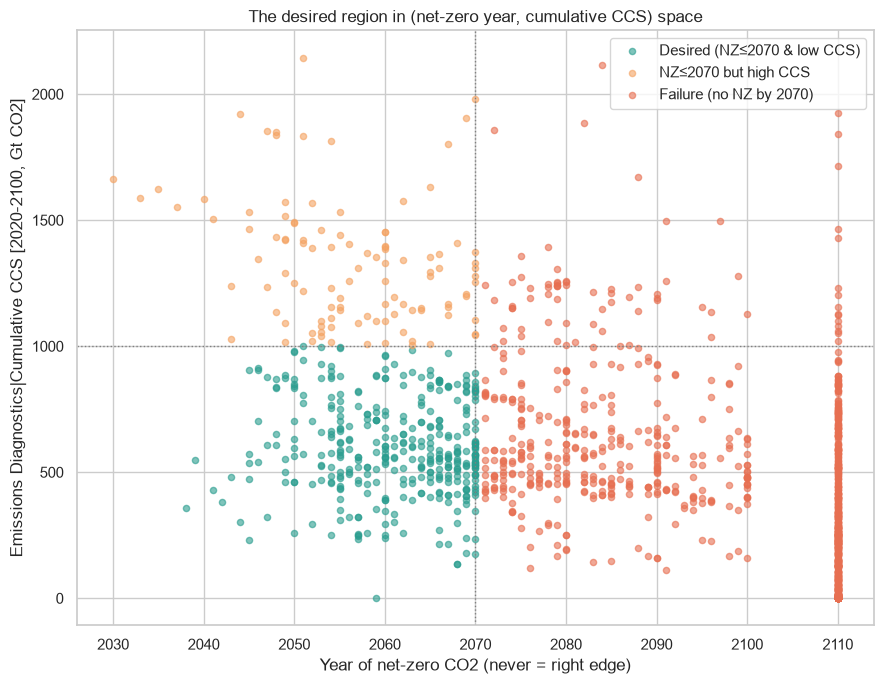

In [7]:
NZ_COL = "Emissions Diagnostics|Year of Net Zero|CO2"
CCS_COL = "Emissions Diagnostics|Cumulative CCS [2020-2100, Gt CO2]"
CCS_THRESHOLD = 1000
nz_plot_year = df[NZ_COL].fillna(df[NZ_COL].max() + 10)

fig, ax = plt.subplots(figsize=(9, 7))
for cat, color in CAT_PALETTE.items():
    m = df["category"] == cat
    ax.scatter(nz_plot_year[m], df.loc[m, CCS_COL], color=color, label=cat, alpha=0.6, s=20)
ax.axvline(2070, color="grey", lw=1, ls=":")
ax.axhline(CCS_THRESHOLD, color="grey", lw=1, ls=":")
ax.set_xlabel("Year of net-zero CO2 (never = right edge)")
ax.set_ylabel(CCS_COL)
ax.set_title("The desired region in (net-zero year, cumulative CCS) space")
ax.legend()
fig.tight_layout()
fig.savefig("desired_region_scatter.png", dpi=150)
plt.show()